# 1. Configuration parameters of the YAML input file

In this tutorial we take a closer look at the PlatoSim configuration parameters stored in the YAML input file. The default `inputfile.yaml` file used by PlatoSim is located in the folder `PlatoSim3/inputfiles/`. We note that this notebook is designed to provide additional information about the YAML file, hence for a full explaination of every single input parameter please consult our [PlatoSim documentation page](http://ivs-kuleuven.github.io/PlatoSim3/index.html).

### Setup Notebook

In [1]:
# Reload code outside notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib inline

### Imports

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

# PlatoSim
import platosim.noise as ns   
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.matplotlibrc import setup_notebook
setup_notebook()

---
## 1.1 - General Overview
---

The YAML input file is structured by the following blocks of information:

- General
- ObservingParameters
- Sky
- Platform
- Telescope
- Camera
- PSF
- FEE
- CCD
- SubField
- Photometry
- RandomSeeds
- ControlHDF5Content
- ControlTcpConnection
- CameraGroups
- CCDPositions

We will ellaborate on the must important parameters within these blocks in the following. We recommend that you either open the YAML file with an appropiate program or use the following code snippet to get an overview of the input parameters stored in the YAML file:

In [3]:
# Use the default YAML file and print its content
sim = Simulation("output_tutorial11")
sim.showYamlConfiguration()

CCD:
  BFE:
    CoefficientsFileName: inputfiles/a_bfe.hdf5
  CTI:
    Model: Short2013
    Short2013:
      Beta: 0.37
      NumTrapSpecies: 4
      ReleaseTime:
        - 0.000237
        - 0.0243
        - 0.00203
        - 0.14
      Temperature: 203.0
      TrapCaptureCrossSection:
        - 2.46e-20
        - 1.74e-22
        - 7.05e-23
        - 2.45e-23
      TrapDensity:
        BOL:
          - 0.0
          - 0.0
          - 0.0
          - 0.0
        EOL:
          - 9.8
          - 3.31
          - 1.56
          - 13.24
    Short2013FromFile:
      CTIFileName: inputfiles/ctiInput.hdf5
    Simple:
      MeanCTE: 0.99999
  ChargeInjection:
    FirstRow: 50
    InjectionLevel: 90.0
    RowInterval: 100
  Contamination:
    MolecularContaminationEfficiency: 0.9573
    ParticulateContaminationEfficiency: 0.972
  DarkSignal:
    DSNU: 15.0
    DarkCurrent: 1.2
    Stability: 5.0
  DigitalSaturation: 65535
  FirstRowExposed: 0
  FlatfieldNoiseRMS: 0.01
  FullWellSaturation: 90

---
## 1.2 - Reference frames
---

As a start we here take a look at how PlatoSim configures the spacecraft and generally sets up a simulation. As a top-down overview PlatoSim models the multi-camera payload configuration as illustrated in the figure below:

<img src="../../figures/SpacecraftColor.png" width="600"/>

The sky pointing for PLATO is linked to the platform pointing (and not the spacecraft poiting as typically used for other spacecrafts). Due to the opening angle for each of the four camera groups, the platform pointing is not identical to the pointing of the cameras. The camera pointing (i.e. the optical axis) can be derived from the platform pointing, and the tilt and azimuth angle. It is possible to figure the pointing of the Camera using the `Telescope` block (note Telescope is PlatoSim's internal naming convention):

    Telescope:
    
        GroupID:                        Custom    # 1, 2, 3, 4, Fast, or Custum
        AzimuthAngle:                   0.0       # [deg]
        TiltAngle:                      0.0       # [deg]
    
In case `GroupID = Custom`, the values for the tilt and azimuth angle will be read from the `Telescope` block.  In case of a pre-defined camera group (i.e. `GroupID = 1, 2, 3, 4, or Fast`), the appropriate values will automatically be selected from the `CameraGroups` block:

    CameraGroups:                        # Do not alter these!
    
        AzimuthAngle:                    [45.0, 135.0, 225.0, 315.0, 0.0]
        TiltAngle:                       [9.2, 9.2, 9.2, 9.2, 0.0]
        
Note that **you should not alter any values from the CameraGroup block** unless you really attend to setup PlatoSim for a different payload configuration!

PlatoSim uses several reference frames to model incident light from the sky through the camera and on to the focal plane. As an overview we here show the CCD focal plane with the difference reference frames used internally by PlatoSim:

<img src="../../figures/FocalPlaneCoordinateSystem.png" width="750"/>

Note that the butting distance (here: 2 mm) has not been updated (to 2.6 mm) yet in this figure.



More information about the sets of reference frame transformation is given in the PlatoSim paper. For now, whats important to know, is how to select a custom CCD position for your target(s). 

    CCD: 
    
        Position:                        Custom    # 1, 2, 3, 4, or Custum

In case `position = Custom`, the values for the origin offset, orientation, dimensions, and first illuminated row will be read from the `CCD` block.  In case of a pre-defined CCD position (i.e. `GroupID = 1, 2, 3, or 4`), the appropriate values will be selected from the `CCDPositions` block:

    CCDPositions:                        # Do not alter these!
    
        OriginOffsetX:                   [-1.3, -1.3, -1.3, -1.3]
        OriginOffsetY:                   [82.48, 82.48, 82.48, 82.48]
        Orientation:                     [180, 270, 0, 90] 
        NumColumns:                      [4510, 4510, 4510, 4510]
        NumRows:                         [4510, 4510, 4510, 4510]
        FirstRowForNormalCamera:         [0, 0, 0, 0]
        FirstRowForFastCamera:           [2255, 2255, 2255, 2255]

Again, note that **you should not alter any value from the CCDPositions block** unless you really attend to setup PlatoSim for a different payload configuration!

---
## 1.2 - General Parameters
---

Below we highlight a few important parameters that you need to consider if the goal is to produce realistic simulations of PLATO's future observations.

#### Observing parameters

The observing parameter block is one of the must important blocks for you as a user. It is here you change the number of exposures you want simulate, change the cadence, etc.:

    ObservingParameters:

        MissionDuration:          6.5           # [yrs]
        NumExposures:             10            # Exposures
        BeginExposureNr:          0             # Sequential number
        CycleTime:                25            # Cycle time [s]
        Fluxm0:                   1.00179e8     # V=0 G2V-star [photons/s/m^2/nm]
        StarCatalogFile:          inputfiles/starcat.txt
        
Minimally you'll need to provide a star catalogue. Luckily, PlatoSim uses the Long-duration Observational Phase (LOP) South field from the PLATO Input Catalogue (PIC 1.1) as default.

Notice that PlatoSim uses the Johnson-Cousin V magnitude as reference flux. If you provide your catalogue in magnitudes of the PLATO passband, you will need to change `Fluxm0` to the current best estimate of `0.7324478224428527e8`. 

#### Sky pointing of platform

As mentioned above the default pointing (alpha, delta, kappa) corresponds to the LOP South field. If you want to simulate a time series of several quarters where the platform rotates along its roll axis with an angle of 90 degrees, you need to break up the time series in different mission quarters, and manual set up the solar panel orientation. See the block:

    Platform:

        Orientation:
          Source:                    Angles      # Either "Angles" or "Quaternion" 
          Angles:
            RAPointing:              86.8        # Platform right ascension [deg]
            DecPointing:            -46.4        # Platform declination     [deg]
            SolarPanelOrientation:   -8.5        # Spacecraft roll angle    [deg]
          Quaternion:                            # [q0, qx, qy, qz] with norm = 1.0
            Components:              [1.0, 0.0, 0.0, 0.0] 
            
Note that you can also use the unit quaternion to transform from the equatorial to the platfrom reference frame. Generally this is not needed and use mainly used by the PLATO Performance team.

#### The subfield

Simulating a full frame CCD image is very time consuming. Thus, PlatoSim has a very nice feature where you can select a smaller part of a given CCD to simulate, which we refer to a **subfield**. The `SubField` block is where you manually can select which part of the CCD and how big of a subfield you would like to simulate:

    SubField:

        ZeroPointRow:                0           # [pixels]
        ZeroPointColumn:             0           # [pixels]
        NumColumns:                  100         # [pixels]
        NumRows:                     100         # [pixels]
        NumBiasPrescanRowd:          15          # [pixels]
        NumBiasPrescanColumns:       25          # [pixels]
        NumSmearingOverscanRows:     30          # [pixels]
        SubPixels:                   8           # Should be 2^n <= 128.

Note that the `SubField` block is also where you select the sizes of the precan and overscan regions that are used e.g. in the pre-processing of your raw pixel data prior to the photometric extraction. Be very careful of setting the subpixel size below 128 in steps of $2^n$ subpixels. The higher this value, the longer the computation time. 

We here highlight a few important examples that concern the limitation of simulating subfields compared to full-frame CCD images:

 - the absence of incident light at the pixel-edges from stars just outside the subfield.
 - the absence of smearing and/or blooming trails from bright stars located in shared pixel columns but outside the subfield
 - flux anomalies from stars "falling off" the subfield during a simulation due to a pixel displacement caused by the AOCS jitter, the TED, the KDA, or a combination of these. 
 
Such effects are particularly important for simulation studies where an realistic star catalogue containing stellar contaminants is employed. We note, however, that the latter anomaly can be avoided by logically choosing an appropriate subfield size, given the prior information about the star catalogue and the included instrumental systematics. 


#### Sky background

Here we take a closer look at the `Sky` block:

    Sky:

        SkyBackground:
          UseConstantSkyBackground:      yes
          BackgroundValue:               -1

If `UseConstantSkyBackground = yes`, every pixel sees the same background, otherwise the background gets calculated ones for every pixel. If we set this parameter to `no` a more realistic gradient will be calculated across the subfield (on the expense of a longer computation time). Note that this is only true if the `SkyBackground` parameter is set to `-1`. In this case the sky background is automatically selected from an interpolated sky map.

The automatic sky background includes zodiacal light and Galactic light. Stray light is not yet implemented in PlatoSim since generally such a model is highly dependent on the Sun-Earth-Moon celestial configuration with respect to where the camera are pointing. Such a model will hopefully be implemented in the future.

#### Kinematic aberration

Since the PLATO spacecraft orbits in the L2 point, the spacecrafts movement relative to the stars observed introduce Kinematic Aberration. The fine guinding sensor (the F-CAMs) can partially correction for this but there will be residual aberration across the FOV of each camera. By default aberration is included using an realistic L2 orbit file:

    Camera:

        IncludeAberrationCorrection:     yes             # Calculate and apply
        AberrationCorrection:
            Type:                        differential    # [differential, absolute]
            OrbitFile:                   inputfiles/orbit.txt
            StartTime:                   101489.207030

Note you can also activate the absolute kinematic aberration, however, in flight this is not representative for the N-CAMs.


#### Random seeds

The random seed below are used by the different noise generators of PlatoSim. Selecting proper "seeds" for each of these are very important if you want to micmic the future observations of PLATO:

    RandomSeeds:    
    
        ReadOutNoiseSeed:            1424949740
        PhotonNoiseSeed:             1433320336
        JitterSeed:                  1433320381
        FlatFieldSeed:               1425284070
        DriftSeed:                   1433429158
        CosmicSeed:                  1494750830
        DarkSignalSeed:              1468838669


If you are simulating smaller subfields (like an imagette) for a duration up to a full mission quarter, in order to simulate one star at a time, then you need to take care of all the seeds:

 - For each star: the seeds `ReadoutNoiseSeed`, `FlatFieldSeed`, and `DarkSignalSeed` need to be the different for all simulations, since the random noise fluctuation varies spatially across the FPA.
 - For each star: the `PhotonNoiseSeed` and `CosmicSeed` need to be different since the arrival of incident light follows a Poisson distibution and varies spatially across the FPA.
 - For each camera: the `DriftSeed` needs to be different, but still the same for all stars observed with the same camera.
 - For all simulations: the `JitterSeed` needs to be the same since the jitter is identical for all stars and only varies over time.

---
## 1.3 - Red noise generators
---

Depending on the exact purpose of your simulations, you may want to alter the used modelf for AOCS jitter and thermal-elastic distortion (TED) of the simulated camera. Pointing variations of the payload (i.e. the platform and the cameras), are described in terms of Euler angles (yaw, pitch, roll) illustrated in the figure below.

<img src="../../figures/PayloadReferenceFrame.png" width="600"/>

Since it is an art in itself to make a realistic simulation of AOCS jitter, PlatoSim provide an alternative using a **Red Noise** (or "random walk") model. Such a model it also available for the TED drift. The Jitter and Drift parameters are the following:

- standard deviation of normal distribution describing (yaw, pitch, roll) step
- timescale

The noise will be generated in the time domain with the following power spectral density:

$$P(\nu) = \frac{\sigma^2 \tau}{1 + (2\pi\nu\tau)^2}$$

where $\sigma$ is the VarScale, and $\tau$ is the TimeScale.

Highly realistic simulation of the jitter noise component typically means that a small time step needs to be considered (like 0.125s or 8 Hz). However, one needs to be a bit pragmatic if the goal is to simulate a full mission quarter. Note that the if the jitter time scale is larger than the cadence, then this time scale will fall back to the cadence. The acutally time scale used internally within PlatoSim is 1/10th of the jitter time scale. We recommend to never use a jitter time scale larger than 10 times the cadence (i.e. 250s for the normal N-CAM cadence), since discontinuities may be observed in the simulated time series. Note PlatoSim may give a more realistic light curve if you use a simple polynomial for the TED.

Below you can play around with the model parameters for a few red noise models:

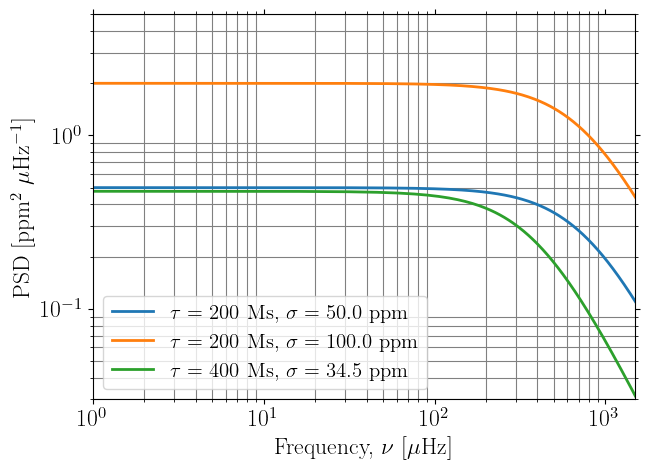

In [4]:
# Construct input arrays
freq  = np.linspace(1, 1500, 200)          # [Ms]
tau   = np.array([200, 200, 400]) * 1e-6   # [Ms]
sigma = np.array([50, 100, 34.5])          # [ppm]

# Make plot of red noise model
fig = plt.figure(figsize = (7, 5))
for i in range(len(tau)):
    plt.loglog(freq, ns.modelRedNoisePSD(freq, [tau[i]], [sigma[i]]), lw=2, 
               label=r"$\tau=$ " + f"{tau[i]*1e6:.0f}" + r" Ms, $\sigma=$ " + str(sigma[i]) + " ppm")
plt.grid(True, which='minor', axis='both', linestyle='-', color='gray')
plt.xlabel(r"Frequency, $\nu$ [$\mu$Hz]")
plt.ylabel(r"PSD [ppm$^2$ $\mu$Hz$^{-1}$]")
plt.xlim(1.0, 1500)
plt.ylim(0.03, 5)
plt.legend()
plt.show()

---
## 1.3- Supplementary files
---

PlatoSIm uses several supplementary files to setup a realisitic model of the PLATO payload. We here show the files that the you may consider configuring.

#### Star Catalogue

The star catalogue belongs to the `ObservingParameters/StarCatalogFile` entry. 

Include one row per source:
- right ascension [degrees]
- desclination [degrees]
- magnitude

The follwoing is an example:

#### Variable Sources

The Variable Souce List belongs to the `Sky/VariableSourceList` entry. 

Include one row per source:
- Star ID in catalogue
- Location of ascii file with noise-less time series

As an example this looks like the following for two target stars:

```
0    /path/to/varsource0.txt
1    /path/to/varsource1.txt
```

The Variable Source Files above include one row per source like:
- time [s]
- step in delta magnitude

The follwoing is an example:

#### Jitter and Drift from file

The Jitter from file belongs to the `Platform/JitterFileName` entry and Drift from file belongs to the `Telescope/DriftFileName` entry. 

Include one row per Jitter/Drift time step:
- time [s]
- step in yaw [arcsec]
- step in pitch [arcsec]
- step in roll [arcsec]

The follwoing is an example:

#### PSF files

If case you want to use pre-computed normalised PSFs, you must provide these in the form of an HDF5-file. The path of this file, relative to the project location, is specified via the `MappedFromFile: Filename` parameter in the PSF block in the configuration file:

    PSF:

        Model:                       AnalyticNonGaussian      # PSF model
        MappedFromFile:                                       # Pre-computed PSF
            Filename:                inputfiles/PSF_Focus_0mu.hdf5
            NumberOfPixels:          8                        # Field size [pixel]
            ChargeDiffusionStrength: 0.2                      # [pixel]
            IncludeChargeDiffusion:  yes                      # [yes or no]
            IncludeJitterSmoothing:  no                       # [yes or no]
        AnalyticNonGaussian:
            ParameterFileName:       inputfiles/apsf_N6000K_v2.txt
            ChargeDiffusionStrength: 0.2                      # Width [pixels]
            IncludeChargeDiffusion:  yes                      # [yes or no]
            Sigma:                                            # Width [pixel]
                Source:              ConstantValue            # or FromFile
                ConstantValue:       0.5                      # [pixel]
                FromFile:            inputfiles/sigmaPSF.txt  # time & sigma
            
            

The simulator will automatically select the PSF for which the angular distance to the optical axis matches best for the simulated sub-field.

In case you want to use an analytic non-Gaussian PSF (`Model = AnalyticGaussian` in the PSF block), you must provide the parameters characterising it in a file in ASCII format. The most recent values for these parameters can be found in the file `apsf_N6000K_v2.txt` file in the `inputfiles/` directory.

Additionally, if required (`AnalyticNonGaussian: Sigma: Source = FromFile` in the PSF block), a time series for the width of the analytic non-Gaussian PSF must be provided in a file in ASCII format. This file should contain columns, separated by a space, holding the following information:

- Time [s]
- Width of the PSF [pixel].

The path of this file, relative to the project location, must be provided via the AnalyticNonGaussian: Sigma: FromFile parameter in the Camera block in the configuration file. 

---
**Below we show the non-diffused PSF grids across the FPA that are used by default in PlatoSim:**

#### Zemax PSF
<img src="../../figures/psf_N6000K_Zemax.png" width="700"/>

#### Analytic PSF
<img src="../../figures/psf_N6000K_Analytical.png" width="700"/>

### Files you *can change for special applications*

Since PlatoSim is fully configurable you can further change several settings. These belongs to the category of "special" simulations and care must be taken while including new realistic models representable for PLATO. Have a look at:

- `Camera/FocalPlaneOrientation/FromFile`
- `Camera/FocalLength/FromFile`
- `Camare/AberrationCorrection/OrbitFile`
- `Camera/FieldDistortion/CoefficientsFromFile`
- `Camera/FieldDistortion/InverseCoefficientsFromFile`
- `FEE/TemperatureFileName`
- `CCD/BFE/CoefficientsFileName`
- `CCD/TemperatureFileName`

---
## 1.5 - In need of more input models?
---

In case that the provided files do not satisfy your demand, additional files exist on our FTP server that easily can be downloaded: 

[Download from the FTP-server](http://ivs-kuleuven.github.io/PlatoSim3/_reqs_run.html).